In [38]:
## import all libraries :-

In [39]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import binom
from matplotlib import pyplot as plt 
from matplotlib_venn import venn2

In [40]:
## Loading the dataset :-

In [41]:
df = pd.read_csv('expectation_decider_dataset.csv')
df

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,33,66,No,48,Pass
1,19,75,No,68,Fail
2,12,85,No,96,Pass
3,25,61,Yes,74,Pass
4,23,60,No,42,Fail
...,...,...,...,...,...
195,29,78,No,32,Pass
196,27,91,Yes,52,Pass
197,35,60,Yes,47,Pass
198,34,64,No,67,Pass


### Types of Events

In [42]:
## - Empirical Probability 

In [43]:
total_students = len(df)

students_passed = len(df[df['final_exam_pass'] == 'Pass'])

empirical_prob = students_passed/ total_students
print(f"Empirical Probability (Passed student):- {empirical_prob}")

Empirical Probability (Passed student):- 0.645


In [44]:
## - Theoretical Probability :-

In [45]:
theoretical_prob = 1 / 2
print(f"Theoretical Probability (Group Discussion):- {theoretical_prob}")

Theoretical Probability (Group Discussion):- 0.5


In [46]:
## Calculate Probability :-

In [47]:
total_students = len(df)
print(f"Total Students:- {total_students}")

students_passed = len(df[df['final_exam_pass'] == 'Pass'])
print(f"Student Who Passed :- {students_passed}")

p = students_passed / total_students
print("Probability of Passing (p) :- ", round(p, 4))

Total Students:- 200
Student Who Passed :- 129
Probability of Passing (p) :-  0.645


### Define Random Variable X

In [48]:
n = 3
p = 0.645

x_values = np.arange(0, n + 1)

print("Possible outcomes for X :- ", x_values)



Possible outcomes for X :-  [0 1 2 3]


In [49]:
## Probability Distribution Table :-

In [50]:
probabilities = stats.binom.pmf(x_values, n, p)

dist_table = pd.DataFrame({
    'Number of Passes (X)': x_values,
    'Probability P(X)': np.round(probabilities, 4)
})

print("\n--- Probability Distribution Table ---")
dist_table


--- Probability Distribution Table ---


,Number of Passes (X),Probability P(X)
0,0,0.0447
1,1,0.2439
2,2,0.4431
3,3,0.2683


In [51]:
## Sum of probability :-

In [52]:
print(f"Sum of probabilities :- {round(probabilities.sum())}")

Sum of probabilities :- 1


In [53]:
## Mean and Variance of this random variable :-

In [54]:
mean = n * p

variance = n * p * (1 - p)

print("Mean of X :- ", round(mean, 3))
print("Variance of X :- ", round(variance, 3))

Mean of X :-  1.935
Variance of X :-  0.687


### Venn Diagram 

In [55]:
A = df[df["study_hours"] > 10]

B = df[df["attendance"] > 80]

A_and_B = df[(df["study_hours"] > 10) & (df["attendance"] > 80)]

only_A = len(A) - len(A_and_B)
only_B = len(B) - len(A_and_B)
both = len(A_and_B)

only_A, only_B, both

(73, 24, 90)

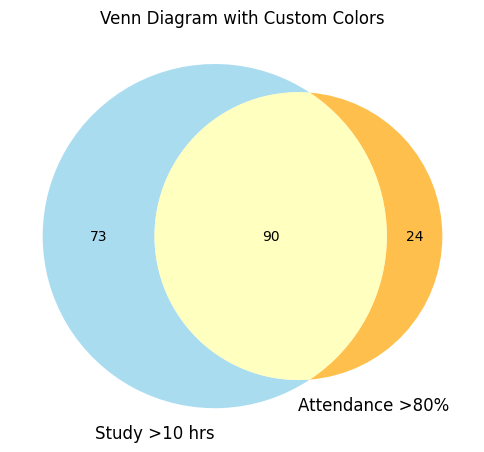

In [56]:
plt.figure(figsize=(6,6))

venn2(subsets=(only_A, only_B, both), 
      set_labels=("Study >10 hrs", "Attendance >80%"),
      set_colors=('skyblue', 'orange'),  
      alpha=0.7)                        

plt.title("Venn Diagram with Custom Colors")
plt.show()

### Contingency Table & Probability Calculations

In [57]:
## Create a Contingency Table :- 

In [58]:
contingency_table = pd.crosstab(df["group_discussion"], df["final_exam_pass"])

contingency_table

final_exam_pass,Fail,Pass
group_discussion,,
No,40,51
Yes,31,78


In [59]:
## Joint Probability :-

In [60]:
total_students = contingency_table.values.sum()

total_students

np.int64(200)

In [61]:
joint_yes_pass = contingency_table.loc["Yes","Pass"] / total_students
joint_yes_fail = contingency_table.loc["Yes","Fail"] / total_students
joint_no_pass = contingency_table.loc["No","Pass"] / total_students
joint_no_fail = contingency_table.loc["No","Fail"] / total_students

In [62]:
joint_probability_table = pd.DataFrame({
    "Fail": [joint_no_fail, joint_yes_fail],
    "Pass": [joint_no_pass, joint_yes_pass]
}, index=["Not Discussion", "Discussion"])

joint_probability_table

,Fail,Pass
Not Discussion,0.200,0.255
Discussion,0.155,0.390


In [63]:
## Marginal Probability :-

In [64]:
prob_dis = contingency_table.loc["Yes"].sum() / total_students
print("P(Discussion) =", prob_dis)

prob_no_dis = contingency_table.loc["No"].sum() / total_students
print("P(Not Discussion) =", prob_no_dis)

prob_pass = contingency_table["Pass"].sum() / total_students
print("P(Pass) =", prob_pass)

prob_fail = contingency_table["Fail"].sum() / total_students
print("P(Fail) =", prob_fail)

P(Discussion) = 0.545
P(Not Discussion) = 0.455
P(Pass) = 0.645
P(Fail) = 0.355


In [65]:
## Independent & Dependent & Mutually Exclusive Events :-

In [66]:
prob_pass_given_dis= (
    contingency_table.loc["Yes","Pass"] /
    contingency_table.loc["Yes"].sum()
)
print("P(Pass | Discussion) =", prob_pass_given_dis)

prob_pass_given_no_dis= (
    contingency_table.loc["No","Pass"] /
    contingency_table.loc["No"].sum()
)
print("P(Pass | Not Discussion) =", prob_pass_given_no_dis)

P(Pass | Discussion) = 0.7155963302752294
P(Pass | Not Discussion) = 0.5604395604395604


### Understanding Relationships

In [67]:
## Independent and Dependent and  Mutually Exclusive Events :-

In [68]:
print("P(Yes ∩ Pass) =", joint_yes_pass)
print("P(Yes) × P(Pass) =", prob_dis * prob_pass)

P(Yes ∩ Pass) = 0.39
P(Yes) × P(Pass) = 0.35152500000000003


### Bayes Theorem Application

In [69]:
prob_dis = contingency_table.loc["Yes"].sum() / total_students

prob_pass = contingency_table["Pass"].sum() / total_students

prob_pass_given_dis= (
    contingency_table.loc["Yes","Pass"] /
    contingency_table.loc["Yes"].sum()
)

In [70]:
prob_discussion_given_pass = (
    prob_pass_given_dis * prob_dis
) / prob_pass

print("P(Discussion | Pass) =", prob_discussion_given_pass)

P(Discussion | Pass) = 0.6046511627906977
